In [1]:
import os
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

print("TabTransformer environment ready!")

TabTransformer environment ready!


In [2]:
DATA_PATH = "/content/DL-Assignment/dataset/apachejit_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Year range:", df["year"].min(), "-", df["year"].max())

FileNotFoundError: [Errno 2] No such file or directory: '/content/DL-Assignment/dataset/apachejit_total.csv'

In [3]:
import os

print("Repository files:")
print(os.listdir("/content/DL-Assignment"))

print("\nDataset files:")
print(os.listdir("/content/DL-Assignment/dataset"))

Repository files:


FileNotFoundError: [Errno 2] No such file or directory: '/content/DL-Assignment'

In [4]:
!git clone -b ushara-eda https://github.com/Jana1805/DL-Assignment.git

Cloning into 'DL-Assignment'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 29 (delta 10), reused 26 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 12.08 MiB | 20.09 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [5]:
import os

print("Repository exists:", os.path.exists("/content/DL-Assignment"))

print("\nDataset files:")
print(os.listdir("/content/DL-Assignment/dataset"))

Repository exists: True

Dataset files:
['apachejit_test_large.csv', 'apachejit_test_small.csv', 'apachejit_total.csv', 'apachejit_total_with_messages.csv', 'apachejit_train.csv']


In [6]:
DATA_PATH = "/content/DL-Assignment/dataset/apachejit_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Year range:", df["year"].min(), "-", df["year"].max())

Dataset loaded successfully!
Shape: (106674, 18)
Year range: 2003 - 2019


In [7]:
DATA_PATH = "/content/DL-Assignment/dataset/apachejit_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Year range:", df["year"].min(), "-", df["year"].max())

Dataset loaded successfully!
Shape: (106674, 18)
Year range: 2003 - 2019


In [8]:
RAW_FEATURE_COLUMNS = [
    "la", "ld", "nf", "nd", "ns", "ent",
    "ndev", "age", "nuc", "aexp", "arexp", "asexp"
]

DERIVED_FEATURES = [
    "total_churn",
    "churn_per_file",
    "files_per_dir",
    "add_delete_ratio",
    "exp_ratio"
]

ALL_FEATURE_COLUMNS = RAW_FEATURE_COLUMNS + DERIVED_FEATURES

LABEL_COLUMN = "buggy"

print("Number of features:", len(ALL_FEATURE_COLUMNS))
print("\nFeatures:")
print(ALL_FEATURE_COLUMNS)
print("\nTarget:", LABEL_COLUMN)

Number of features: 17

Features:
['la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp', 'total_churn', 'churn_per_file', 'files_per_dir', 'add_delete_ratio', 'exp_ratio']

Target: buggy


In [9]:
def engineer_features(frame):
    out = frame.copy()

    out["total_churn"] = out["la"] + out["ld"]
    out["churn_per_file"] = out["total_churn"] / out["nf"].replace(0, 1)
    out["files_per_dir"] = out["nf"] / out["nd"].replace(0, 1)
    out["add_delete_ratio"] = out["la"] / (out["ld"] + 1)
    out["exp_ratio"] = out["arexp"] / (out["aexp"] + 1)

    return out


SKEWED_FEATURES = [
    "la", "ld", "nf", "nd", "ns",
    "ndev", "age", "nuc", "aexp", "arexp", "asexp"
]

LOG_TRANSFORM_COLUMNS = SKEWED_FEATURES + [
    "total_churn",
    "churn_per_file"
]


def apply_log_transform(frame, columns):
    out = frame.copy()

    for col in columns:
        out[col] = np.log1p(out[col])

    return out


# Create derived features
df_engineered = engineer_features(df)

# Apply log transformation
df_engineered = apply_log_transform(
    df_engineered,
    LOG_TRANSFORM_COLUMNS
)

print("Feature engineering completed!")
print("Total features:", len(ALL_FEATURE_COLUMNS))
print("\nFeature columns:")
print(ALL_FEATURE_COLUMNS)

Feature engineering completed!
Total features: 17

Feature columns:
['la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp', 'total_churn', 'churn_per_file', 'files_per_dir', 'add_delete_ratio', 'exp_ratio']


In [10]:
TRAIN_YEAR_MAX = 2014
VAL_YEAR_MIN = 2015
VAL_YEAR_MAX = 2016
TEST_YEAR_MIN = 2017

train_df = df_engineered[
    df_engineered["year"] <= TRAIN_YEAR_MAX
].reset_index(drop=True)

val_df = df_engineered[
    (df_engineered["year"] >= VAL_YEAR_MIN) &
    (df_engineered["year"] <= VAL_YEAR_MAX)
].reset_index(drop=True)

test_df = df_engineered[
    df_engineered["year"] >= TEST_YEAR_MIN
].reset_index(drop=True)

print("Chronological split completed!\n")

print(f"Train      : {len(train_df)} rows | 2003-2014")
print(f"Validation : {len(val_df)} rows | 2015-2016")
print(f"Test       : {len(test_df)} rows | 2017-2019")

Chronological split completed!

Train      : 52133 rows | 2003-2014
Validation : 24430 rows | 2015-2016
Test       : 30111 rows | 2017-2019


In [11]:
X_train = train_df[ALL_FEATURE_COLUMNS].values.astype(np.float32)
y_train = train_df[LABEL_COLUMN].values.astype(np.int64)

X_val = val_df[ALL_FEATURE_COLUMNS].values.astype(np.float32)
y_val = val_df[LABEL_COLUMN].values.astype(np.int64)

X_test = test_df[ALL_FEATURE_COLUMNS].values.astype(np.float32)
y_test = test_df[LABEL_COLUMN].values.astype(np.int64)

print("Feature and label extraction completed!\n")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Feature and label extraction completed!

X_train: (52133, 17)
y_train: (52133,)
X_val: (24430, 17)
y_val: (24430,)
X_test: (30111, 17)
y_test: (30111,)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

print("\nShapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

print("\nTraining mean:")
print(np.round(X_train_scaled.mean(axis=0), 3))

print("\nTraining std:")
print(np.round(X_train_scaled.std(axis=0), 3))

Feature scaling completed!

Shapes:
X_train_scaled: (52133, 17)
X_val_scaled: (24430, 17)
X_test_scaled: (30111, 17)

Training mean:
[ 0. -0.  0.  0.  0.  0. -0.  0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]

Training std:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

# Calculate class weights from training data only
classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

print("Class weights:")
print("Clean (0):", class_weights[0])
print("Buggy (1):", class_weights[1])

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataLoaders created successfully!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Class weights:
Clean (0): 0.7051288987475316
Buggy (1): 1.7187458789397336

DataLoaders created successfully!
Training batches: 204
Validation batches: 96
Test batches: 118


In [14]:
class TabTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        embedding_dim=32,
        num_heads=4,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        # Convert each numerical feature into an embedding
        self.feature_embeddings = nn.Linear(1, embedding_dim)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim * embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x shape: [batch, features]

        # Treat every feature as a separate token
        x = x.unsqueeze(-1)

        # [batch, features, 1]
        x = self.feature_embeddings(x)

        # [batch, features, embedding_dim]
        x = self.transformer(x)

        # Classification
        output = self.classifier(x)

        return output


INPUT_DIM = X_train_scaled.shape[1]

model = TabTransformer(
    input_dim=INPUT_DIM,
    embedding_dim=32,
    num_heads=4,
    num_layers=2,
    dropout=0.3
)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nInput features:", INPUT_DIM)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

TabTransformer(
  (feature_embeddings): Linear(in_features=1, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=544, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_fea

In [15]:
# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Move model to device
model = model.to(device)

# Convert class weights to tensor
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

# Weighted Cross-Entropy Loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("Device:", device)
print("Loss function: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Device: cpu
Loss function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


print("Training and validation functions created successfully!")

Training and validation functions created successfully!


In [17]:
NUM_EPOCHS = 50
PATIENCE = 7

best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save the best validation model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

# Restore the best model
model.load_state_dict(best_model_state)

print("\nBest validation loss:", best_val_loss)
print("TabTransformer training completed!")

Epoch 01/50 | Train Loss: 0.5805 | Train Acc: 0.6975 | Val Loss: 0.5629 | Val Acc: 0.6844
Epoch 02/50 | Train Loss: 0.5651 | Train Acc: 0.7092 | Val Loss: 0.5470 | Val Acc: 0.7221
Epoch 03/50 | Train Loss: 0.5581 | Train Acc: 0.7196 | Val Loss: 0.5395 | Val Acc: 0.7569
Epoch 04/50 | Train Loss: 0.5540 | Train Acc: 0.7228 | Val Loss: 0.5468 | Val Acc: 0.7233
Epoch 05/50 | Train Loss: 0.5487 | Train Acc: 0.7257 | Val Loss: 0.5366 | Val Acc: 0.7516
Epoch 06/50 | Train Loss: 0.5475 | Train Acc: 0.7283 | Val Loss: 0.5431 | Val Acc: 0.7198
Epoch 07/50 | Train Loss: 0.5457 | Train Acc: 0.7309 | Val Loss: 0.5434 | Val Acc: 0.7363
Epoch 08/50 | Train Loss: 0.5425 | Train Acc: 0.7318 | Val Loss: 0.5334 | Val Acc: 0.7417
Epoch 09/50 | Train Loss: 0.5403 | Train Acc: 0.7325 | Val Loss: 0.5394 | Val Acc: 0.7375
Epoch 10/50 | Train Loss: 0.5396 | Train Acc: 0.7340 | Val Loss: 0.5358 | Val Acc: 0.7360
Epoch 11/50 | Train Loss: 0.5377 | Train Acc: 0.7360 | Val Loss: 0.5446 | Val Acc: 0.7235
Epoch 12/5

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(y_batch.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
roc_auc = roc_auc_score(all_labels, all_probabilities)

print("===== TabTransformer Test Results =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Clean", "Buggy"]
    )
)

===== TabTransformer Test Results =====
Accuracy : 0.6846
Precision: 0.3501
Recall   : 0.7382
F1 Score : 0.4750
ROC-AUC  : 0.7710

Classification Report:
              precision    recall  f1-score   support

       Clean       0.91      0.67      0.77     24293
       Buggy       0.35      0.74      0.47      5818

    accuracy                           0.68     30111
   macro avg       0.63      0.71      0.62     30111
weighted avg       0.81      0.68      0.72     30111



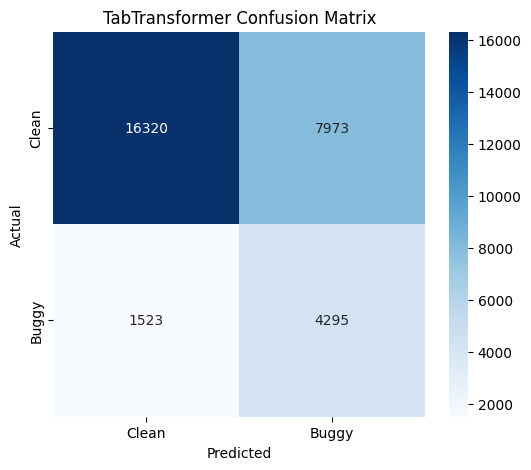

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clean", "Buggy"],
    yticklabels=["Clean", "Buggy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TabTransformer Confusion Matrix")

plt.show()

In [20]:
# Save TabTransformer model
torch.save(
    model.state_dict(),
    "/content/DL-Assignment/tabtransformer_weights.pt"
)

# Save metrics
tabtransformer_metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "roc_auc": float(roc_auc)
}

with open(
    "/content/DL-Assignment/tabtransformer_metrics.json",
    "w"
) as f:
    json.dump(tabtransformer_metrics, f, indent=2)

# Save training history
tabtransformer_history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
}

with open(
    "/content/DL-Assignment/tabtransformer_history.json",
    "w"
) as f:
    json.dump(tabtransformer_history, f, indent=2)

print("TabTransformer model and results saved successfully!")

TabTransformer model and results saved successfully!
